# CardioIA – Fase 2
## Parte 2 – Classificador Básico de Texto

Este notebook irá funcionar localmente e no Google Colab, localizando automaticamente a pasta `data`.

In [1]:
!git clone https://github.com/limadeivisson/cardioia-fase2-diagnostico-automatizado.git

Cloning into 'cardioia-fase2-diagnostico-automatizado'...
remote: Enumerating objects: 21, done.
remote: Counting objects: 100% (21/21), done.
remote: Compressing objects: 100% (18/18), done.
remote: Total 21 (delta 3), reused 21 (delta 3), pack-reused 0 (from 0)
Receiving objects: 100% (21/21), 128.97 KiB | 1.87 MiB/s, done.
Resolving deltas: 100% (3/3), done.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [3]:
def localizar_base():
    candidatos = [
        Path('.'),
        Path('cardioia-fase2-diagnostico-automatizado'),
        Path('/content/cardioia-fase2-diagnostico-automatizado'),
    ]
    for candidato in candidatos:
        if (candidato / 'data').exists():
            return candidato
    raise FileNotFoundError(
        "Não foi possível localizar a pasta 'data'. Se estiver no Colab, clone o repositório primeiro."
    )

base = localizar_base()
print('Base encontrada em:', base.resolve())

Base encontrada em: /content/cardioia-fase2-diagnostico-automatizado


In [4]:
df = pd.read_csv(base / 'data' / 'frases_risco_rotuladas.csv')
display(df.head())

,frase,situacao
0,Sinto dor no peito e falta de ar,alto risco
1,Tenho pressão no tórax e suor frio,alto risco
2,Estou com palpitações e tontura frequente,alto risco
3,Tenho dificuldade para respirar ao caminhar,alto risco
4,Sinto dor irradiando para o braço esquerdo,alto risco


In [5]:
X = df['frase']
y = df['situacao']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

modelo = Pipeline([
    ('tfidf', TfidfVectorizer(lowercase=True, ngram_range=(1, 2))),
    ('clf', LogisticRegression(max_iter=1000))
])

modelo.fit(X_train, y_train)
y_pred = modelo.predict(X_test)

print('Acurácia:', round(accuracy_score(y_test, y_pred), 4))
print('\nRelatório de classificação:\n')
print(classification_report(y_test, y_pred))

Acurácia: 0.4

Relatório de classificação:

              precision    recall  f1-score   support

  alto risco       0.00      0.00      0.00         3
 baixo risco       0.40      1.00      0.57         2

    accuracy                           0.40         5
   macro avg       0.20      0.50      0.29         5
weighted avg       0.16      0.40      0.23         5



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


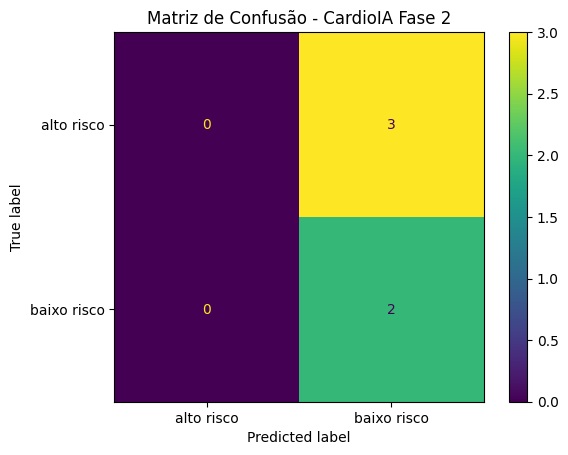

In [6]:
cm = confusion_matrix(y_test, y_pred, labels=modelo.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=modelo.classes_)
disp.plot()
plt.title('Matriz de Confusão - CardioIA Fase 2')
plt.show()

### Se estiver no Google Colab
Execute antes:

```python
!git clone https://github.com/limadeivisson/cardioia-fase2-diagnostico-automatizado.git
```